# PESSD

## Requirements

In [1]:
pip install jupyterlab anywidget tempdisagg

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas_datareader.data as web
import datetime
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from tempdisagg import TempDisaggModel
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

## Data

In [3]:
data_dir = Path("..//..//data")
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"
outputs_dir = data_dir / "outputs"



Comparaison des données dispos dans la base EA-MD-QD

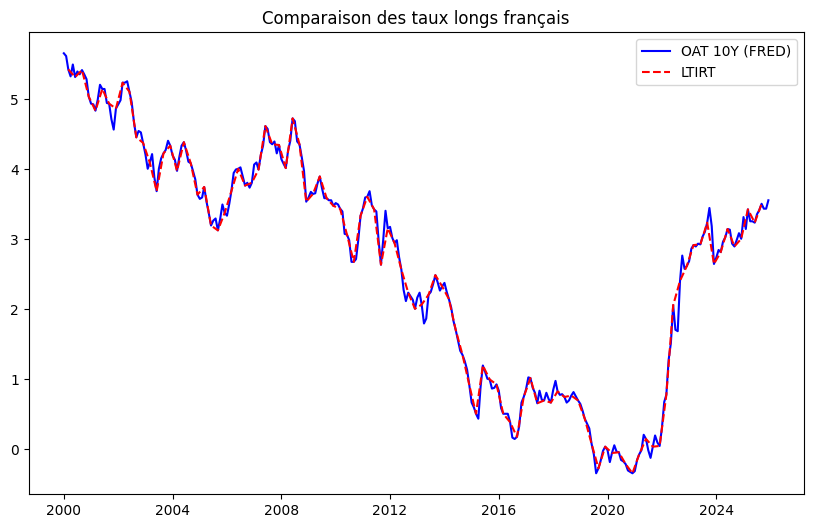

In [4]:
start_date = datetime.datetime(2000, 1, 1)
end_date = datetime.datetime(2025, 12, 31)
oat_fred = web.DataReader('IRLTLT01FRM156N', 'fred', start_date, end_date)

data_fr_raw = pd.read_excel(raw_dir / "FRdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
data_fr = data_fr_raw.copy().drop(columns=['ICONFIX_FR','CCONFIX_FR','ESENTIX_FR','KCONFIX_FR','RTCONFIX_FR','SCONFIX_FR','BCI_FR','CCI_FR'],errors='ignore').dropna()
ltirt = data_fr['LTIRT_FR']

plt.figure(figsize=(10, 6))
plt.plot(oat_fred.index, oat_fred['IRLTLT01FRM156N'], label='OAT 10Y (FRED)', color='blue')
plt.plot(ltirt.index, ltirt, label='LTIRT', color='red', linestyle='--')
plt.title("Comparaison des taux longs français")
plt.legend()
plt.show()

On voit que c'est 99% similaire, donc top !

### Transformation en monthly

In [13]:
def from_quarterly_to_monthly(dataset, info, method="ensemble", default_conversion="average"):
    # 1. Identification simple des fréquences
    quarterly_cols = info.loc[dataset.columns]["Frequency"] == "Q"
    monthly_cols = info.loc[dataset.columns]["Frequency"] == "M"
    
    # 2. Mapping sans condition de flux/stock (on cherche juste la meilleure corrélation)
    mapping = {}
    for q_col in dataset.columns[quarterly_cols]:
        best_corr = 0
        best_m_col = None
        for m_col in dataset.columns[monthly_cols]:
            # Resampling pour corrélation sur la même base
            corr = (dataset[q_col].resample("QE").mean()).corr(
                dataset[m_col].resample("QE").mean()
            )
            if abs(corr) > abs(best_corr):
                best_corr = corr
                best_m_col = m_col
        mapping[q_col] = best_m_col

    # 3. Désagrégation (TempDisaggModel devient indépendant du type flux/stock)
    result = {}
    index = dataset.index.year
    grain = [i % 12 + 1 for i in range(len(dataset))]

    for q_col, m_col in mapping.items():
        # Utilise une conversion par défaut si le type n'est pas précisé
        model = TempDisaggModel(method=method, conversion=default_conversion)
        
        df = pd.DataFrame({
            "Index": index, 
            "Grain": grain, 
            "y": dataset[q_col], 
            "X": dataset[m_col] if m_col is not None else 1.0
        })
        model.fit(df)
        result[q_col] = model.predict()

    m_index = dataset.index
    results_flat = {k: np.asarray(v).reshape(-1) for k, v in result.items()}
    df_q_to_m = pd.DataFrame.from_dict(results_flat, orient="columns")
    df_q_to_m = df_q_to_m[: len(m_index)]
    df_q_to_m.index = m_index[: len(df_q_to_m)]

    df_final = pd.concat([df_q_to_m, dataset.loc[:, monthly_cols]], axis=1)
    return df_final

In [14]:
# ==============================================================================
# FRANCE
# ==============================================================================
data_fr = pd.read_excel(raw_dir / "FRdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
info_fr = pd.read_excel(raw_dir / "FRdata.xlsx", sheet_name="info", index_col=0)

df_fr_monthly = from_quarterly_to_monthly(data_fr, info_fr)
df_fr_monthly.dropna(how="all", inplace=True)

info_fr_monthly = info_fr.copy()
info_fr_monthly.loc[info_fr_monthly["Frequency"] == "Q", "Frequency"] = "M"
#info_fr_monthly.drop(columns=["Type"], inplace=True)

with pd.ExcelWriter(processed_dir / "FRdata_monthly.xlsx") as writer: #, engine="xlsxwriter"
    df_fr_monthly.to_excel(writer, sheet_name="data", index=True)
    info_fr_monthly.to_excel(writer, sheet_name="info", index=True)

print("Traitement terminé pour la France. Fichier 'FRdata_monthly.xlsx' généré.")

Traitement terminé pour la France. Fichier 'FRdata_monthly.xlsx' généré.


In [15]:
# ==============================================================================
# ALLEMAGNE
# ==============================================================================
data_de = pd.read_excel(raw_dir / "DEdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
info_de = pd.read_excel(raw_dir / "DEdata.xlsx", sheet_name="info", index_col=0)

df_de_monthly = from_quarterly_to_monthly(data_de, info_de)
df_de_monthly.dropna(how="all", inplace=True)

info_de_monthly = info_de.copy()
info_de_monthly.loc[info_de_monthly["Frequency"] == "Q", "Frequency"] = "M"


with pd.ExcelWriter(processed_dir / "DEdata_monthly.xlsx") as writer: #, engine="xlsxwriter"
    df_de_monthly.to_excel(writer, sheet_name="data", index=True)
    info_de_monthly.to_excel(writer, sheet_name="info", index=True)

print("Traitement terminé pour l'Allemagne. Fichier 'DEdata_monthly.xlsx' généré.")

Traitement terminé pour l'Allemagne. Fichier 'DEdata_monthly.xlsx' généré.


Il faut process les données grâce au fichier de la BDD pour tout stationnariser (ou alors tout refaire à la main). Pour l'instant j'ai choisi de faire les "Heavy Transformation".

In [16]:
data_fr = pd.read_excel(processed_dir / "FRdataM_HT.xlsx", sheet_name="FR", index_col=0, parse_dates=True)
data_de = pd.read_excel(processed_dir / "DEdataM_HT.xlsx", sheet_name="DE", index_col=0, parse_dates=True)

# Normalement inutile, mais il faut assurer le coup.
if 'LTIRT_FR' not in data_fr.columns:
    data_fr = data_fr.add_suffix('_FR')
if 'LTIRT_DE' not in data_de.columns:
    data_de = data_de.add_suffix('_DE')

# Création d'une base FR+DE
data_joint = data_fr.join(data_de, how='inner')

# On supprime les variables de sentiment de notre base (normalement elles sont toutes là)
sentiment_vars_base = ['ICONFIX', 'CCONFIX', 'ESENTIX', 'KCONFIX', 'RTCONFIX', 'SCONFIX', 'BCI', 'CCI']
cols_to_drop = []

for var in sentiment_vars_base:
    cols_to_drop.extend([f"{var}_FR", f"{var}_DE"])

# On vérifie quelles variables présentes avant de les supprimer
cols_to_drop = [c for c in cols_to_drop if c in data_joint.columns]
data_joint_no_sentiment = data_joint.drop(columns=cols_to_drop)

# On nettoie la base finale
data_joint_clean = data_joint_no_sentiment.dropna()

# On créer un fichier pour éviter de refaire ça.
data_joint_clean.to_csv(processed_dir / "Joint_Macro_Dataset.csv")

print(f"Dimensions de la base conjointe : {data_joint_clean.shape[0]} mois et {data_joint_clean.shape[1]} variables.")
print(f"Variables de sentiment retirées : {len(cols_to_drop)}")
print("Fichier créé !")

Dimensions de la base conjointe : 316 mois et 201 variables.
Variables de sentiment retirées : 16
Fichier créé !


## Traitement

Là l'idée c'est de faire un Factor modèle à partir des données dispos en excluant les indicateurs de confiances !

Donc ici notre $y_t$ c'est directement le spread (France - Allemagne, mais a ajuster au besoin), et les variables explicatives seront les $n$ variables issues de la PCA.

Bon au final les algos choisissent souvent n=1 ou n=2 mais comme on l'a vu avec Perogaro, on s'attend plus à du 3-4 d'après Nelson-Siegal, donc je pars là dessus mais ça reste flexible.

Donc on part sur la régression :

$$y_t = \beta_0 + \beta_1 F_{1,t} + \beta_2 F_{2,t} + \beta_3 F_{3,t} + \beta_4 F_{4,t} + \epsilon_t$$

Et ici ce dont on aura besoin c'est ce $\epsilon_t$ pour utiliser notre sentiment.

In [17]:
# On peut directement recharcher le fichier sans avoir à tout relancer
data_joint = pd.read_csv(processed_dir / "Joint_Macro_Dataset.csv", index_col=0, parse_dates=True)

In [25]:
# On récupère les taux directement des bases initiales (non transformées)
# On peut aussi utiliser FRED si c'est plus pratique
raw_fr = pd.read_excel(processed_dir / "FRdata_monthly.xlsx", sheet_name="data", index_col=0, parse_dates=True)
raw_de = pd.read_excel(processed_dir / "DEdata_monthly.xlsx", sheet_name="data", index_col=0, parse_dates=True)



# On oublie pas de retirer les taux de la base cible...
cols_to_drop = ['LTIRT_FR', 'LTIRT_DE']
sentiment_vars_base = ['ICONFIX', 'CCONFIX', 'ESENTIX', 'KCONFIX', 'RTCONFIX', 'SCONFIX', 'BCI', 'CCI']
for var in sentiment_vars_base:
    cols_to_drop.extend([f"{var}_FR", f"{var}_DE"])

cols_to_drop_existing = [c for c in cols_to_drop if c in data_joint.columns]
X_macro = data_joint.drop(columns=cols_to_drop_existing)


# Je crois qu'il faut vérifier que j'ai les bonnes données mais ça changera pas grand chose en soit
print(f"Nombre de variables macro utilisées pour la PCA : {X_macro.shape[1]}")

Nombre de variables macro utilisées pour la PCA : 199


In [65]:
lr_fr = pd.read_csv(raw_dir / "Rendement de l'Obligation France 10 ans - Données Historiques (1).csv", index_col=0, parse_dates=True)

french_long_rate = lr_fr['Dernier']
french_long_rate.index = pd.to_datetime(french_long_rate.index, dayfirst=True)
french_long_rate = french_long_rate.sort_index(ascending=True)
french_long_rate = french_long_rate[french_long_rate.index >= start_date]
french_long_rate = pd.to_numeric(
    french_long_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)


lr_ger = pd.read_csv(raw_dir / "Rendement de l'Obligation Allemagne 10 ans - Données Historiques.csv", index_col=0, parse_dates=True)
german_long_rate = lr_ger['Dernier']
german_long_rate.index = pd.to_datetime(german_long_rate.index, dayfirst=True)
german_long_rate = german_long_rate.sort_index(ascending=True)
german_long_rate = german_long_rate[german_long_rate.index >= start_date]
german_long_rate = pd.to_numeric(
    german_long_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

spread_brut = french_long_rate - german_long_rate
spread_brut.name = "Spread_OAT_BUND"

spread = spread_brut.diff().dropna()


In [59]:
# Calcul de la PCA

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_macro)

# On impose 4 facteurs (Niveau, Pente, Courbure, etc.)
pca = PCA(n_components=4)
factors = pca.fit_transform(X_scaled)

print(f"Variance macro expliquée par les 4 facteurs : {pca.explained_variance_ratio_.sum()*100:.2f}%\n")

# On stock
df_factors = pd.DataFrame(factors, index=X_macro.index, columns=['F1', 'F2', 'F3', 'F4'])
df_daily_factors = df_factors.resample('D').interpolate(method='linear')

Variance macro expliquée par les 4 facteurs : 44.27%



In [62]:
df_daily_factors.loc[start_date:end_date]

,F1,F2,F3,F4
Time,,,,
2020-12-01,3.746577,8.288201,11.930281,-2.071786
2020-12-02,3.967948,9.132269,12.521595,-2.133717
2020-12-03,4.189319,9.976338,13.112910,-2.195649
2020-12-04,4.410690,10.820407,13.704224,-2.257580
2020-12-05,4.632061,11.664475,14.295539,-2.319512
...,...,...,...,...
2025-11-27,3.377404,1.664640,-1.757833,-0.565276
2025-11-28,3.435491,1.663636,-1.782671,-0.650743
2025-11-29,3.493578,1.662633,-1.807510,-0.736211


In [66]:
# Régression + correction de l'autocorrelation (NEWEY-WEST)

df_daily_factors = df_daily_factors.loc[spread.index]

X_reg = sm.add_constant(df_daily_factors.loc[start_date:end_date])
model = sm.OLS(spread, X_reg).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

print("--- RÉSULTATS DE LA RÉGRESSION ---")
print(model.summary())

--- RÉSULTATS DE LA RÉGRESSION ---
                            OLS Regression Results                            
Dep. Variable:        Spread_OAT_BUND   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1728
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.952
Time:                        15:54:16   Log-Likelihood:                 3323.1
No. Observations:                1281   AIC:                            -6636.
Df Residuals:                    1276   BIC:                            -6610.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.

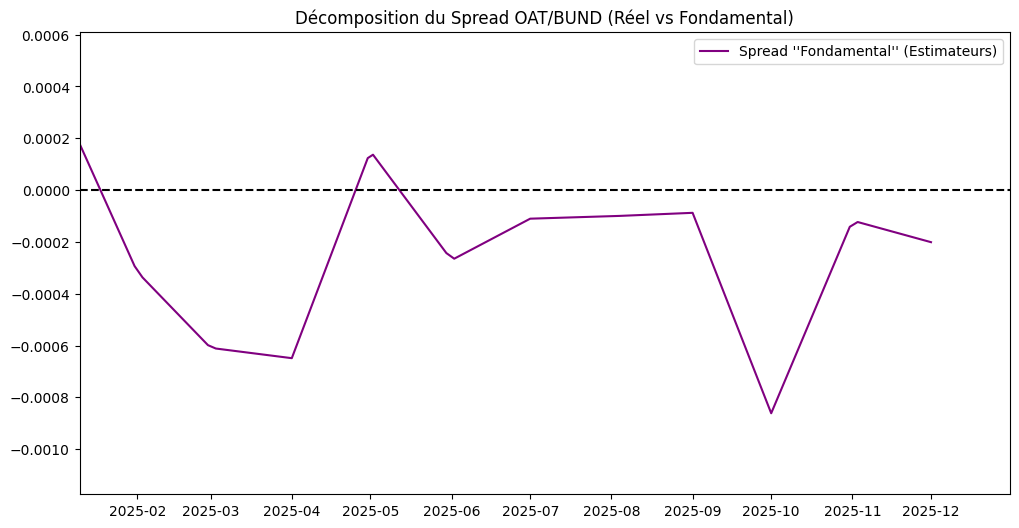

In [69]:
# On plot
residuals = model.resid
residuals.name = "Epsilon"


start_date = datetime.date(2025, 1, 10)
end_date = datetime.date(2025, 12, 31)
plt.figure(figsize=(12, 6))
#plt.plot(spread.index, spread, label="Spread OAT-BUND (Réel)", color='blue', alpha=0.8, linewidth=2)
plt.plot(residuals.index, residuals-spread, label="Spread ''Fondamental'' (Estimateurs)", color='purple', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--')
plt.title("Décomposition du Spread OAT/BUND (Réel vs Fondamental)")
plt.xlim([start_date, end_date])
plt.legend()
plt.show()

In [70]:
# On exporte pour tout avoir à dispo
residuals.to_csv(outputs_dir / "epsilon_spread.csv")
print("\nRésidus sauvegardés dans 'epsilon_spread.csv'.")


Résidus sauvegardés dans 'epsilon_spread.csv'.


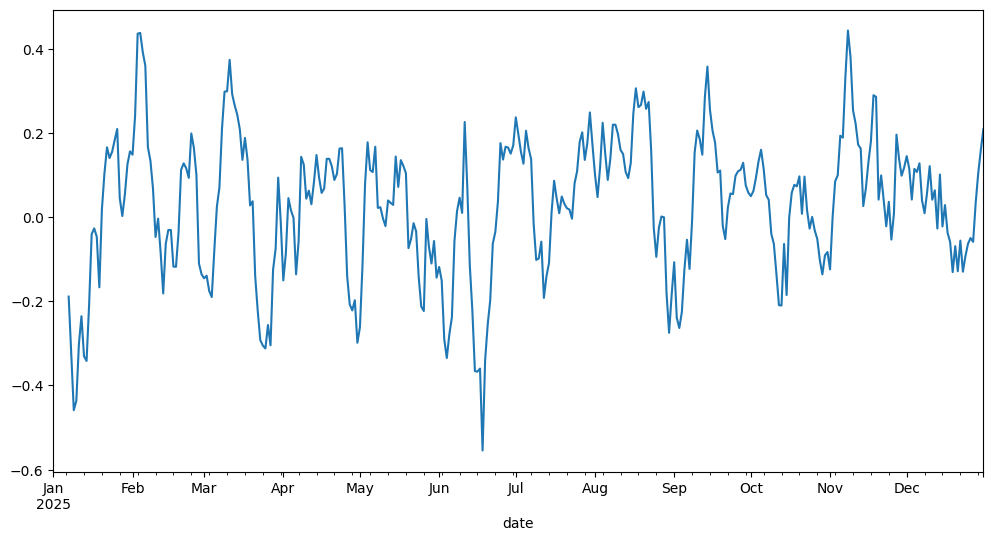

In [37]:
sentiments = pd.read_csv("..\\..\\data\\news_processed\\aggregated_daily_finbert.csv", index_col=0, parse_dates=True)
sentiments['diff_ma7'].plot(figsize=(12, 6))

sent = sentiments['diff_ma7'].dropna()
sentiment_FR = sentiments['sent_fr_ma7'].dropna()
sentiment_DE = sentiments['sent_de_ma7'].dropna()

In [39]:
german_uncertainty = pd.read_csv("..\\..\\data\\other_indices\\DEEPUINDXM.csv", index_col=0, parse_dates=True)
german_uncertainty.index = pd.to_datetime(german_uncertainty.index)
german_uncertainty = german_uncertainty[german_uncertainty.index >= start_date]
german_uncertainty.plot(figsize=(12, 6))

french_uncertainty = pd.read_csv("..\\..\\data\\other_indices\\FREUINDXM.csv", index_col=0, parse_dates=True)
french_uncertainty.index = pd.to_datetime(french_uncertainty.index)
french_uncertainty = french_uncertainty[french_uncertainty.index >= start_date]
french_uncertainty.plot(figsize=(12, 6))

TypeError: Invalid comparison between dtype=datetime64[ns] and date

In [71]:
sentiment_FR_lag = sentiment_FR.shift(1)
sentiment_FR_lag = sentiment_FR_lag.fillna(method='ffill').fillna(method='bfill')
sentiment_DE_lag = sentiment_DE.shift(1)
sentiment_DE_lag = sentiment_DE_lag.fillna(method='ffill').fillna(method='bfill')

C:\Users\elyan\AppData\Local\Temp\ipykernel_30824\797712990.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sentiment_FR_lag = sentiment_FR_lag.fillna(method='ffill').fillna(method='bfill')
C:\Users\elyan\AppData\Local\Temp\ipykernel_30824\797712990.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sentiment_DE_lag = sentiment_DE_lag.fillna(method='ffill').fillna(method='bfill')


In [73]:
index_to_regress = residuals.index.intersection(sentiment_FR_lag.index).intersection(sentiment_DE_lag.index)
reg_data = pd.DataFrame({
    "Epsilon": residuals.loc[index_to_regress],
    "Sentiment_FR": sentiment_FR_lag.loc[index_to_regress],
    "Sentiment_DE": sentiment_DE_lag.loc[index_to_regress],
    "sentiment_DE_lag" : sentiment_DE_lag.loc[index_to_regress],
    "sentiment_FR_lag" : sentiment_FR_lag.loc[index_to_regress],
    "Sentiment_FR-DE" : (sentiment_FR - sentiment_DE).loc[index_to_regress]
})

In [74]:
epsilon = reg_data["Epsilon"]
reg_data.drop(columns=["Epsilon"], inplace=True)
X_reg = sm.add_constant(reg_data)
model_sent = sm.OLS(epsilon, X_reg).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print("--- RÉSULTATS DE LA RÉGRESSION AVEC SENTIMENTS ---")
print(model_sent.summary())

--- RÉSULTATS DE LA RÉGRESSION AVEC SENTIMENTS ---
                            OLS Regression Results                            
Dep. Variable:                Epsilon   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     1.122
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.341
Time:                        15:55:51   Log-Likelihood:                 601.52
No. Observations:                 232   AIC:                            -1195.
Df Residuals:                     228   BIC:                            -1181.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

c:\Users\elyan\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
